In [1]:
import warnings

import janitor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from utilities.graph_utils import save_mpl_fig
from utilities.utils import get_fulldata, pandas_to_tex, process_land_area

warnings.filterwarnings("ignore")
sns.set_theme(context="notebook", font_scale=1.5, style="whitegrid")

FP_LLM = "../data/llm_names_sex_religion.parquet"

/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:88: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:92: DeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:88: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:92: DeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/home/lsys/land/venv_land/lib/python3.10/site-packages/matplotlib/_fontconfig_pattern.py:88: DeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/home/lsys/land/venv_land/lib/python3.10/site-packa

In [2]:
usecols = ["account_no", "name_of_ryot", "6", "7", "8"]
df = (
    get_fulldata(usecols=usecols, low_memory=False)
    .pipe(process_land_area)
    .merge(
        (
            pd.read_parquet(
                FP_LLM,
                columns=["name", "entity_type", "religion", "prop_hindu", "prop_muslim"],
            )
            .query("entity_type == 'human'")
            .query("religion != 'cannot_decide'")
            .remove_columns("entity_type")
            .drop_duplicates("name")
            .rename_column("name", "name_of_ryot")
        ),
        how="inner",
        on="name_of_ryot",
        validate="m:1",
    )
    .assign(religion=lambda df_: np.where(df_["religion"] == "muslim", "muslim", "not-muslim"))
)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32959713 entries, 0 to 32959712
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   name_of_ryot  object 
 1   account_no    int64  
 2   acres         float64
 3   decimals      float64
 4   hectare       float64
 5   tt_area_acre  float64
 6   religion      object 
 7   prop_hindu    float64
 8   prop_muslim   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 2.2+ GB


,name_of_ryot,account_no,acres,decimals,hectare,tt_area_acre,religion,prop_hindu,prop_muslim
0,कपिलदेव पाठक,1801010001000002,0.0,66.0,0.0,0.66,not-muslim,0.90,0.05
1,कपिलदेव पाठक,1801010001000002,0.0,8.0,0.0,0.08,not-muslim,0.90,0.05
2,कपिलदेव पाठक,1801010001000002,0.0,6.0,0.0,0.06,not-muslim,0.90,0.05
3,कपिलदेव पाठक,1801010001000002,0.0,3.0,0.0,0.03,not-muslim,0.90,0.05
4,कपिलदेव पाठक,1801010001000002,0.0,36.0,0.0,0.36,not-muslim,0.90,0.05
...,...,...,...,...,...,...,...,...,...
32959708,मु. मंचनिया,1402151675000018,0.0,9.0,0.0,0.09,not-muslim,0.95,0.03
32959709,मु. मंचनिया,1402151675000018,0.0,11.0,0.0,0.11,not-muslim,0.95,0.03
32959710,मु. मंचनिया,1402151675000018,0.0,6.0,0.0,0.06,not-muslim,0.95,0.03
32959711,मु. मंचनिया,1402151675000018,0.0,11.0,0.0,0.11,not-muslim,0.95,0.03


In [3]:
df["name_of_ryot"].nunique()

2809397

In [4]:
df["account_no"].nunique()

10634198

In [5]:
100 * len(df.query("religion=='not-muslim'")) / len(df.dropna(subset=["religion"]))

88.27533176639008

In [6]:
100 * len(df.query("religion=='muslim'")) / len(df.dropna(subset=["religion"]))

11.724668233609922

## Summary numbers

In [7]:
n_land_muslim = len(df.query("religion=='muslim'"))
perc_land_muslim = 100 * n_land_muslim / len(df)

print(f"{n_land_muslim:,.0f} ({perc_land_muslim:.1f}%) land plots are owned by muslim")

3,864,417 (11.7%) land plots are owned by muslim


In [8]:
df_num_plots = (
    df.groupby(["account_no", "religion"])
    .size()
    .reset_index()
    .rename_column(0, "nplots")
)
df_num_plots.head(3)

,account_no,religion,nplots
0,101010273000001,not-muslim,2
1,101010273000002,not-muslim,8
2,101010273000004,not-muslim,3


In [9]:
n_accounts_muslim = len(df_num_plots.query("religion=='muslim'"))
perc_accounts_muslim = 100 * n_accounts_muslim / len(df_num_plots)

print(
    f"{n_accounts_muslim:,.0f} ({perc_accounts_muslim:.1f}%) accounts are under muslim"
)

1,666,069 (15.7%) accounts are under muslim


## Number of plots per account, by religion

In [10]:
ntiles = [
    0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 1,
]
tab_nplot_perc_nonmuslim = (
    df_num_plots.query("religion=='not-muslim'")
    .nplots.quantile(ntiles)
    .reset_index()
    .rename_column("index", "Percentile")
    .rename_column("nplots", "nplots_nonmuslim")
    .astype({"nplots_nonmuslim": int})
)
tab_nplot_perc_muslim = (
    df_num_plots.query("religion=='muslim'")
    .nplots.quantile(ntiles)
    .reset_index()
    .rename_column("index", "Percentile")
    .rename_column("nplots", "nplots_muslim")
    .astype({"nplots_muslim": int})
)
tab_nplot_perc = (
    tab_nplot_perc_muslim
    .merge(tab_nplot_perc_nonmuslim, on="Percentile", how="left", validate="1:1")
    .assign(
        nplots_muslim=lambda df: df.nplots_muslim.map("{:,.0f}".format),
        nplots_nonmuslim=lambda df: df.nplots_nonmuslim.map("{:,.0f}".format),
    )
)
pandas_to_tex(
    tab_nplot_perc,
    "../tables/percentiles_landplots_per_accountholder_religion_llm",
    float_format="%.2f",
)
tab_nplot_perc

,Percentile,nplots_muslim,nplots_nonmuslim
0,0.00,1,1
1,0.10,1,1
2,0.20,1,1
3,0.30,1,1
4,0.40,1,1
5,0.50,1,1
6,0.60,1,1
7,0.70,2,2
8,0.80,2,3
9,0.90,4,7


In [11]:
LINESTYLES = ["-", "--"]
DISPLOT_OPTS = dict(
    aspect=1.5,
    height=6,
    hue="religion",
    legend=False,
    palette="cividis",
    linewidth=2.5,
)
HISTDENSITY_OPTS = dict(
    hue="religion",
    legend=False,
    palette="cividis",
)

LEGEND_OPTS = {
    "title": "",
    "loc": "best",
    "labels": ["Muslim", "Non-Muslim"],
    "frameon": False,
    "fontsize": 24,
    "handletextpad": 0.3,
}

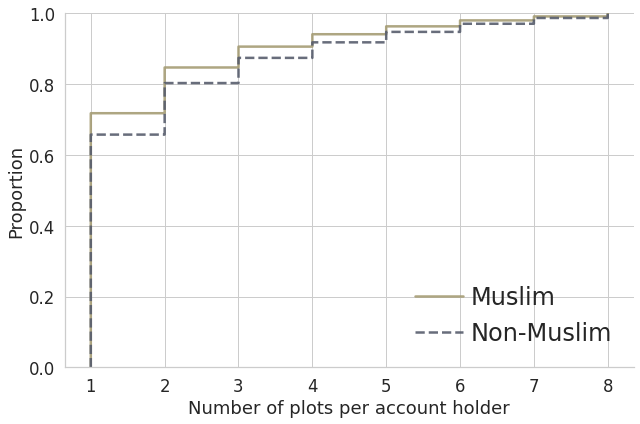

In [12]:
_n = 8

g = sns.displot(
    x="nplots",
    data=df_num_plots.query(f"nplots<={_n}"),
    alpha=0.9,
    kind="ecdf",
    **DISPLOT_OPTS,
)
for line, linestyle in zip(g.axes[0][0].lines, LINESTYLES):
    line.set_linestyle(linestyle)
plt.legend(**LEGEND_OPTS)
plt.xlabel("Number of plots per account holder")
save_mpl_fig("../figures/number_plots_per_accountholder_ecdf_religion_llm")

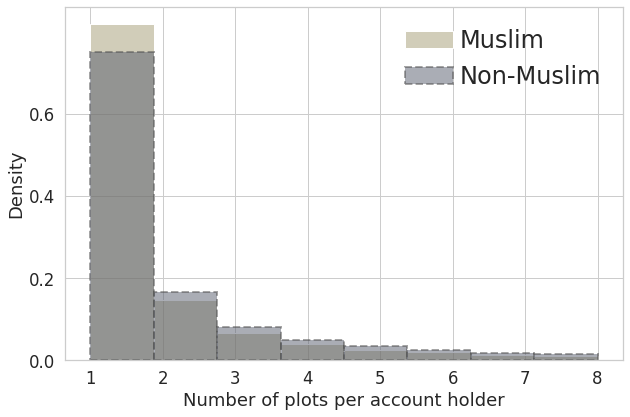

In [13]:
_, ax = plt.subplots(figsize=(10, 6.5))
sns.histplot(
    data=df_num_plots.query(f"nplots<={_n}"),
    x="nplots",
    bins=_n,
    stat="density",
    common_norm=False,
    **HISTDENSITY_OPTS,
    alpha=0.5,
    ax=ax,
)
plt.xlabel("Number of plots per account holder")
plt.yticks([0, 0.2, 0.4, 0.6])

bars = ax.containers[1].get_children()
for bar in bars:
    bar.set_linestyle("--")
    bar.set_linewidth(2)
    bar.set_edgecolor("0.3")
    bar.set_alpha(0.5)
plt.legend(**LEGEND_OPTS)
save_mpl_fig("../figures/number_plots_per_accountholder_histogram_religion_llm")

## Land area per account, by religion

In [14]:
df_landarea = (
    df.groupby(["account_no", "religion"])["tt_area_acre"]
    .sum()
    .reset_index()
)
df_landarea.head(3)

,account_no,religion,tt_area_acre
0,101010273000001,not-muslim,0.585
1,101010273000002,not-muslim,1.545
2,101010273000004,not-muslim,0.340


In [15]:
ntiles = [
    0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 1,
]
tab_area_perc_nonmuslim = (
    df_landarea.query("religion=='not-muslim'")
    .tt_area_acre.quantile(ntiles)
    .reset_index()
    .rename_column("index", "Percentile")
    .rename_column("tt_area_acre", "area_nonmuslim")
)
tab_area_perc_muslim = (
    df_landarea.query("religion=='muslim'")
    .tt_area_acre.quantile(ntiles)
    .reset_index()
    .rename_column("index", "Percentile")
    .rename_column("tt_area_acre", "area_muslim")
)
tab_area_perc = (
    tab_area_perc_muslim
    .merge(tab_area_perc_nonmuslim, on="Percentile", how="left", validate="1:1")
    .assign(
        area_muslim=lambda df: df.area_muslim.map("{:,.2f}".format),
        area_nonmuslim=lambda df: df.area_nonmuslim.map("{:,.2f}".format),
    )
)
pandas_to_tex(
    tab_area_perc,
    "../tables/percentiles_landarea_per_accountholder_religion_llm",
    float_format="%.2f",
)
tab_area_perc

,Percentile,area_muslim,area_nonmuslim
0,0.00,0.00,0.00
1,0.10,0.04,0.03
2,0.20,0.08,0.07
3,0.30,0.13,0.13
4,0.40,0.21,0.21
5,0.50,0.31,0.32
6,0.60,0.45,0.49
7,0.70,0.66,0.75
8,0.80,1.04,1.21
9,0.90,2.00,2.42


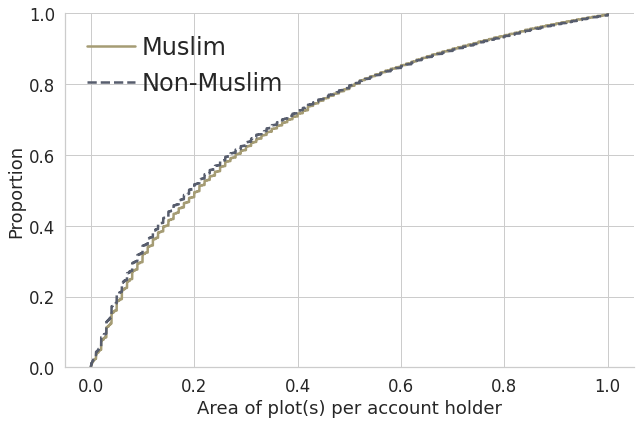

In [16]:
_area = 1

g = sns.displot(
    x="tt_area_acre",
    data=df_landarea.query(f"tt_area_acre<={_area}"),
    kind="ecdf",
    **DISPLOT_OPTS,
)
for line, linestyle in zip(g.axes[0][0].lines, LINESTYLES):
    line.set_linestyle(linestyle)
plt.legend(**LEGEND_OPTS)
plt.xlabel("Area of plot(s) per account holder")
save_mpl_fig("../figures/plot_area_per_accountholder_ecdf_religion_llm")

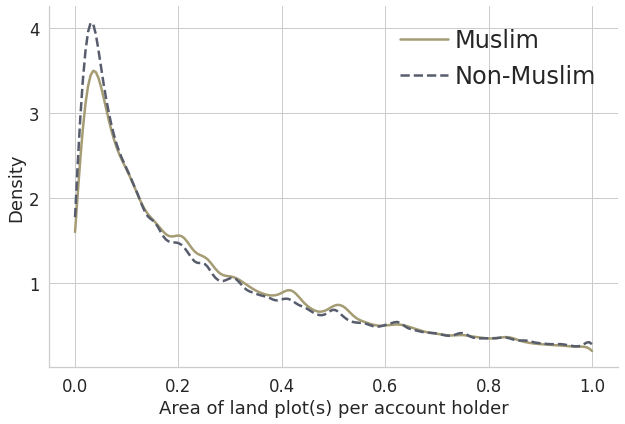

In [17]:
g = sns.displot(
    data=df_landarea.query(f"tt_area_acre<={_area}"),
    x="tt_area_acre",
    kind="kde",
    common_norm=False,
    **DISPLOT_OPTS,
    cut=0,
)
g.set_xlabels("Area of land plot(s) per account holder")
plt.locator_params(axis="y", nbins=5)
for line, linestyle in zip(g.axes[0][0].lines, LINESTYLES):
    line.set_linestyle(linestyle)
plt.legend(**LEGEND_OPTS)
save_mpl_fig("../figures/plot_area_per_accountholder_kde_religion_llm")

In [18]:
_x = "tt_area_acre"
df_landshares = (
    df.groupby(["religion"])[_x].sum().reset_index()
    .assign(landshare=lambda df_: 100 * (df_[_x] / df_[_x].sum()))
    .rename_column(_x, "land")
)
rounding_error = 0.01
assert rounding_error > (100 - df_landshares["landshare"].sum())
df_landshares

,religion,land,landshare
0,muslim,2.961850e+06,10.604773
1,not-muslim,2.496756e+07,89.395227


In [19]:
_x = "nplots"
df_plotshares = (
    df_num_plots.groupby(["religion"])[_x].sum().reset_index()
    .assign(plotshare=lambda df_: 100 * (df_[_x] / df_[_x].sum()))
    .rename_column(_x, "plots")
)
assert df_plotshares["plotshare"].sum() == 100
df_plotshares

,religion,plots,plotshare
0,muslim,3864417,11.724668
1,not-muslim,29095296,88.275332


In [20]:
# pct_bihar_muslim = 0.169 per muslims_dist.ipynb (Wikipedia: Bihari Muslims by district)
df_shares = (
    df_plotshares.merge(df_landshares, on=["religion"], how="left", validate="1:1")
    .sort_values("landshare", ascending=False, ignore_index=True)
    .assign(landshare_cs=lambda df_: df_["landshare"].cumsum())
    .assign(plotshare_cs=lambda df_: df_["plotshare"].cumsum())
    .reorder_columns(["religion", "plots", "plotshare", "plotshare_cs"])
    .assign(base_adultpop=[83.1, 16.9])
    .assign(religion=["Not-Muslim", "Muslim"])
)
df_shares

,religion,plots,plotshare,plotshare_cs,land,landshare,landshare_cs,base_adultpop
0,Not-Muslim,29095296,88.275332,88.275332,2.496756e+07,89.395227,89.395227,83.1
1,Muslim,3864417,11.724668,100.000000,2.961850e+06,10.604773,100.000000,16.9
